# Kinetic and canonic momentum comparison with or without Coulomb gauge

### Simulation parameters

In [1]:
import numpy as np

# hbar * c [GeV * fm]
hbarc = 0.197326 

# Simulation box 
L = 1.0      
# N = 256
N = 128
tau_sim = 0.2
DTS = 16
# DTS = 8

# Derived parameters
a = L/N
E0 = N / L * hbarc
DT = 1.0 / DTS
maxt = int(tau_sim / a * DTS)
nplus = maxt//DTS

# Glasma fields
su_group = 'su3'
uv = 10.0
ir = 0.2
g2mu = 1.5

g = 2         		
mu = g2mu / g**2

ns = 50      

nevents = 1
quark = 'jet' # 'jet' or 'static'            
# quark = 'static'

# coulomb_gauge_mode = 'every_step' # 'none' or 'every_step' or 'initial'
coulomb_gauge_mode = 'initial'

### Enviroment variables

In [2]:
import os

os.environ["MY_NUMBA_TARGET"] = "numba"
import warnings
from numba.core.errors import NumbaPerformanceWarning
warnings.filterwarnings('ignore', category=NumbaPerformanceWarning)

# Comment this, I need it for JYU GPUs to choose a specific GPU to run on
# os.environ["CUDA_VISIBLE_DEVICES"]="1"
# os.environ["MY_NUMBA_TARGET"] = "cuda"
os.environ["PRECISION"] = "double"
os.environ["GAUGE_GROUP"] = su_group

# Import relevant modules
import sys
sys.path.append('..')

# Glasma modules
import curraun.core as core
import curraun.mv as mv
import curraun.initial as initial
initial.DEBUG = False

from curraun.numba_target import use_cuda
if use_cuda:
    from numba import cuda

# Qhat module
if quark=='jet':
    import curraun.qhat_qeik as qeik
    import curraun.qhat_original as qhat
    # import curraun.qhat_qeik_old as qeik
elif quark=='static':
    import curraun.kappa_qeik as qeik
    import curraun.kappa as qhat

import curraun.coulomb as coulomb
coulomb.DEBUG = False

from tqdm import tqdm

Using Numba
Using SU(3)
Using double precision


In [3]:
def simulate_qhat(ev, coulomb_gauge_mode='none'): 
    """
    Run qhat simulation with optional Coulomb gauge fixing.
    
    Parameters:
    -----------
    ev : int
        Event number for progress display
    coulomb_gauge_mode : str
        'none' - no Coulomb gauge fixing
        'initial' - apply Coulomb gauge only at initial time (tint=tstart, when a0 is computed)
        'every_step' - apply Coulomb gauge at every timestep
    """
    # Derived parameters
    a = L / N
    E0 = N / L * hbarc
    DT = 1.0 / DTS
    maxt = int(tau_sim / a * DTS)

    # Initialize Glasma fields
    mv.set_seed(314)
    s = core.Simulation(N, DT, g)
    va = mv.wilson(s, mu=mu / E0, m=ir / E0, uv=uv / E0, num_sheets=ns)
    vb = mv.wilson(s, mu=mu / E0, m=ir / E0, uv=uv / E0, num_sheets=ns)
    initial.init(s, va, vb)

    # Initialize the Qhat module
    qeik_tforce = qeik.KineticCanonicCheck(s)  
    xplus = []
    dpcan_sq, dpkin_sq, da_sq = [], [], []
    da_transp_sq, dpcanda, dpcanda_transp = [], [], []
    intfa, da = [], []

    qhat_tforce = qhat.TransportedForce(s)
    mom_broad =  []

    if use_cuda:
        s.copy_to_device()
        qeik_tforce.copy_to_device()
        qhat_tforce.copy_to_device()

    # Determine gauge label for progress bar
    gauge_labels = {
        'none': 'no Coulomb',
        'initial': 'Coulomb at t=1',
        'every_step': 'Coulomb every step'
    }
    gauge_label = gauge_labels.get(coulomb_gauge_mode, coulomb_gauge_mode)
    
    # For 'initial' mode, we apply Coulomb gauge at tint=tstart (when a0 is computed)
    # This is when s.t = 1.0, which happens at loop iteration t = DTS
    tstart = DTS  # This is when tint == tstart in qeik_tforce.compute()
    
    with tqdm(total=maxt, desc=f"Event {ev+1} ({gauge_label})") as pbar:
        for t in range(maxt):
            # Apply Coulomb gauge transformation based on mode
            # For 'initial' mode, apply at t=DTS (when s.t=1.0 and a0 will be computed)
            apply_coulomb = (
                (coulomb_gauge_mode == 'every_step') or 
                (coulomb_gauge_mode == 'initial' and t == tstart)
            )
            
            if apply_coulomb:
                # Create Coulomb gauge transformation object
                c = coulomb.CoulombGaugeTransf(s)
                
                # Copy c to device if using CUDA (s is already on device)
                if use_cuda:
                    c.copy_to_device()
                
                # Perform gauge fixing entirely on GPU (or CPU if use_cuda=False)
                coulomb.gauge_fix(c, qeik_tforce=qeik_tforce)
                
                # No need to copy back - everything stays on device
            
            qeik_tforce.compute()
            qhat_tforce.compute()
            
            if t % DTS == 0:
                
                if use_cuda:
                    qeik_tforce.copy_to_host()
                    qhat_tforce.copy_mean_to_host()

                # Units GeV^2
                dpcan_sq.append(qeik_tforce.dpcan_sq_mean * E0 ** 2)
                dpkin_sq.append(qeik_tforce.dpkin_sq_mean * E0 ** 2)
                da_sq.append(qeik_tforce.da_sq_mean * E0 ** 2)
                da_transp_sq.append(qeik_tforce.da_transp_sq_mean * E0 ** 2)
                dpcanda.append(qeik_tforce.dpcanda_mean * E0 ** 2)
                dpcanda_transp.append(qeik_tforce.dpcanda_transp_mean * E0 ** 2)
                # Units GeV^-1
                xplus.append(2*t*a/DTS/hbarc)

                mom_broad.append(qhat_tforce.p_perp_mean * E0 ** 2)

                # No units
                intfa_sim = qeik_tforce.intfa.copy()
                intfa.append(intfa_sim[:, :, :])
                da_sim = qeik_tforce.da.copy()
                da.append(da_sim[:, :, :])

                if use_cuda:
                    qeik_tforce.copy_to_device()
                    qhat_tforce.copy_mean_to_device()
            
            # Evolve Glasma fields
            core.evolve_leapfrog(s)

            pbar.update(1)
    
    if use_cuda:
        cuda.current_context().deallocations.clear()

    return xplus, dpcan_sq, dpkin_sq, da_sq, da_transp_sq, dpcanda, dpcanda_transp, np.array(intfa), np.array(da), mom_broad

In [4]:
# Run simulations without Coulomb gauge
print("Running simulations WITHOUT Coulomb gauge transformation")

collect_dpcan_sq_no_coulomb, collect_dpkin_sq_no_coulomb = [], []
collect_da_sq_no_coulomb, collect_da_transp_sq_no_coulomb = [], []
collect_dpcanda_no_coulomb, collect_dpcanda_transp_no_coulomb = [], []
collect_mom_broad_no_coulomb = []

for ev in range(nevents): 
    xplus, dpcan_sq_ev, dpkin_sq_ev, da_sq_ev, da_transp_sq_ev, dpcanda_ev, dpcanda_transp_ev, intfa_no_coulomb, da_no_coulomb, mom_broad_ev = simulate_qhat(ev, coulomb_gauge_mode='none')

    collect_dpcan_sq_no_coulomb.append(dpcan_sq_ev)
    collect_dpkin_sq_no_coulomb.append(dpkin_sq_ev)
    collect_da_sq_no_coulomb.append(da_sq_ev)
    collect_da_transp_sq_no_coulomb.append(da_transp_sq_ev)
    collect_dpcanda_no_coulomb.append(dpcanda_ev)
    collect_dpcanda_transp_no_coulomb.append(dpcanda_transp_ev)
    collect_mom_broad_no_coulomb.append(mom_broad_ev)

dpcan_sq_no_coulomb = np.mean(collect_dpcan_sq_no_coulomb, axis=0)
dpkin_sq_no_coulomb = np.mean(collect_dpkin_sq_no_coulomb, axis=0)
da_sq_no_coulomb = np.mean(collect_da_sq_no_coulomb, axis=0)
da_transp_sq_no_coulomb = np.mean(collect_da_transp_sq_no_coulomb, axis=0)
dpcanda_no_coulomb = np.mean(collect_dpcanda_no_coulomb, axis=0)
dpcanda_transp_no_coulomb = np.mean(collect_dpcanda_transp_no_coulomb, axis=0)  
mom_broad_no_coulomb = np.mean(collect_mom_broad_no_coulomb, axis=0)

Running simulations WITHOUT Coulomb gauge transformation


Event 1 (no Coulomb): 100%|██████████| 409/409 [00:10<00:00, 39.65it/s] 


In [5]:
# Run simulations with Coulomb gauge (mode from cell-2)
print(f"Running simulations WITH Coulomb gauge transformation (mode: {coulomb_gauge_mode})")

collect_dpcan_sq_coulomb, collect_dpkin_sq_coulomb = [], []
collect_da_sq_coulomb, collect_da_transp_sq_coulomb = [], []
collect_dpcanda_coulomb, collect_dpcanda_transp_coulomb = [], []
collect_mom_broad_coulomb = []

for ev in range(nevents): 
    xplus, dpcan_sq_ev, dpkin_sq_ev, da_sq_ev, da_transp_sq_ev, dpcanda_ev, dpcanda_transp_ev, intfa_coulomb, da_coulomb, mom_broad_ev = simulate_qhat(ev, coulomb_gauge_mode)

    collect_dpcan_sq_coulomb.append(dpcan_sq_ev)
    collect_dpkin_sq_coulomb.append(dpkin_sq_ev)
    collect_da_sq_coulomb.append(da_sq_ev)
    collect_da_transp_sq_coulomb.append(da_transp_sq_ev)
    collect_dpcanda_coulomb.append(dpcanda_ev)
    collect_dpcanda_transp_coulomb.append(dpcanda_transp_ev)
    collect_mom_broad_coulomb.append(mom_broad_ev)

dpcan_sq_coulomb = np.mean(collect_dpcan_sq_coulomb, axis=0)
dpkin_sq_coulomb = np.mean(collect_dpkin_sq_coulomb, axis=0)
da_sq_coulomb = np.mean(collect_da_sq_coulomb, axis=0)
da_transp_sq_coulomb = np.mean(collect_da_transp_sq_coulomb, axis=0)
dpcanda_coulomb = np.mean(collect_dpcanda_coulomb, axis=0)
dpcanda_transp_coulomb = np.mean(collect_dpcanda_transp_coulomb, axis=0)  
mom_broad_coulomb = np.mean(collect_mom_broad_coulomb, axis=0)

Running simulations WITH Coulomb gauge transformation (mode: initial)


Event 1 (Coulomb at t=1):   4%|▍         | 16/409 [00:17<00:09, 40.80it/s]

Coulomb gauge condition reached in 13549 iterations with theta=9.99e-13


Event 1 (Coulomb at t=1): 100%|██████████| 409/409 [01:28<00:00,  4.65it/s] 


---
### Comparison kinetic and canonic momentum broadening without and with Coulomb gauge

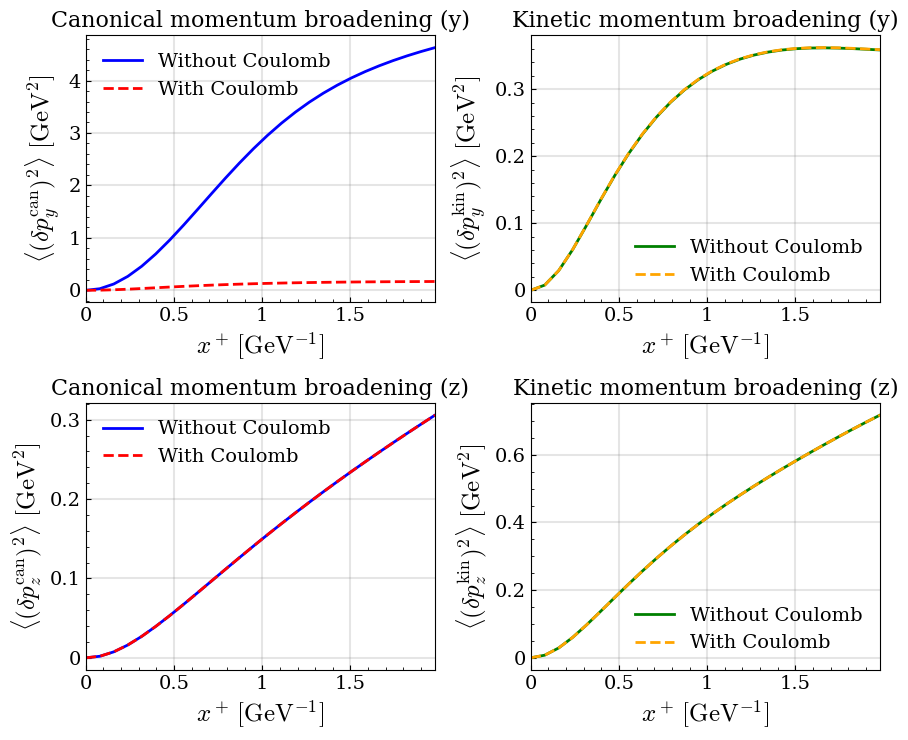

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'

fig, axes = plt.subplots(2, 2, figsize=(9, 7.5))

labels = ['x', 'y', 'z']
directions = [1, 2]  # y and z
direction_labels = ['y', 'z']

# Plot pcan_sq comparison (left column)
for idx, i in enumerate(directions):
    ax = axes[idx, 0]
    
    line1, = ax.plot(xplus, dpcan_sq_no_coulomb[:, i], linewidth=2.0, 
                     color='blue', label=f'Without Coulomb')
    line2, = ax.plot(xplus, dpcan_sq_coulomb[:, i], linewidth=2.0, 
                     color='red', linestyle='--', label=f'With Coulomb')
    
    ax.set_xlim([0, max(xplus)])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.set_xlabel(r"$x^+\,\mathrm{[GeV^{-1}]}$", fontsize=18)
    ax.set_ylabel(rf"$\langle (\delta p^{{\mathrm{{can}}}}_{labels[i]})^2\rangle\,\,\mathrm{{[GeV^2]}}$", fontsize=18)
    ax.set_title(f'Canonical momentum broadening ({direction_labels[idx]})', fontsize=16)
    ax.grid(color='gray', linestyle='-', linewidth=1.5, alpha=0.2)
    ax.tick_params(axis='both', which='major', direction='in', labelsize=14)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', direction='in')
    ax.legend(fontsize=14, frameon=False)

# Plot pkin_sq comparison (right column)
for idx, i in enumerate(directions):
    ax = axes[idx, 1]
    
    line1, = ax.plot(xplus, dpkin_sq_no_coulomb[:, i], linewidth=2.0, 
                     color='green', label=f'Without Coulomb')
    line2, = ax.plot(xplus, dpkin_sq_coulomb[:, i], linewidth=2.0, 
                     color='orange', linestyle='--', label=f'With Coulomb')
    
    ax.set_xlim([0, max(xplus)])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.set_xlabel(r"$x^+\,\mathrm{[GeV^{-1}]}$", fontsize=18)
    ax.set_ylabel(rf"$\langle (\delta p^{{\mathrm{{kin}}}}_{labels[i]})^2\rangle\,\,\mathrm{{[GeV^2]}}$", fontsize=18)
    ax.set_title(f'Kinetic momentum broadening ({direction_labels[idx]})', fontsize=16)
    ax.grid(color='gray', linestyle='-', linewidth=1.5, alpha=0.2)
    ax.tick_params(axis='both', which='major', direction='in', labelsize=14)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', direction='in')
    ax.legend(fontsize=14, frameon=False)

plt.tight_layout()
# plt.savefig(f'pcan_pkin_coulomb_comparison_{quark}_n_{N}_{coulomb_gauge_mode}.png', facecolor='w', dpi=600)
plt.show()

---
## Combined comparison plot

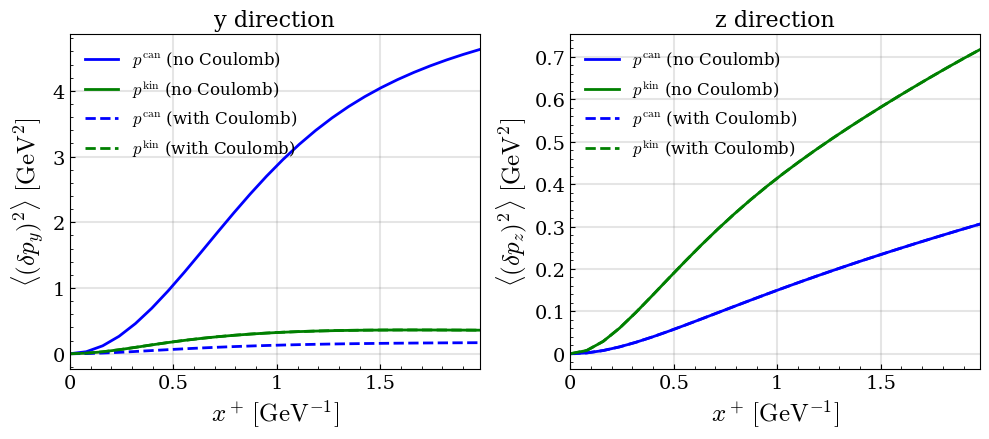

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

labels = ['x', 'y', 'z']
directions = [1, 2]  # y and z
direction_labels = ['y', 'z']

for idx, i in enumerate(directions):
    ax = axes[idx]
    
    # Plot both pcan and pkin for without Coulomb
    line1, = ax.plot(xplus, dpcan_sq_no_coulomb[:, i], linewidth=2.0, 
                     color='blue', label=rf'$p^{{\mathrm{{can}}}}$ (no Coulomb)')
    line2, = ax.plot(xplus, dpkin_sq_no_coulomb[:, i], linewidth=2.0, 
                     color='green', label=rf'$p^{{\mathrm{{kin}}}}$ (no Coulomb)')
    
    # Plot both pcan and pkin for with Coulomb
    line3, = ax.plot(xplus, dpcan_sq_coulomb[:, i], linewidth=2.0, 
                     color='blue', linestyle='--', label=rf'$p^{{\mathrm{{can}}}}$ (with Coulomb)')
    line4, = ax.plot(xplus, dpkin_sq_coulomb[:, i], linewidth=2.0, 
                     color='green', linestyle='--', label=rf'$p^{{\mathrm{{kin}}}}$ (with Coulomb)')
    
    ax.set_xlim([0, max(xplus)])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.set_xlabel(r"$x^+\,\mathrm{[GeV^{-1}]}$", fontsize=18)
    ax.set_ylabel(rf"$\langle (\delta p_{labels[i]})^2\rangle\,\,\mathrm{{[GeV^2]}}$", fontsize=18)
    ax.set_title(f'{direction_labels[idx]} direction', fontsize=16)
    ax.grid(color='gray', linestyle='-', linewidth=1.5, alpha=0.2)
    ax.tick_params(axis='both', which='major', direction='in', labelsize=14)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', direction='in')
    ax.legend(fontsize=12, frameon=False)

plt.tight_layout()
# plt.savefig(f'combined_coulomb_comparison_{quark}_n_{N}_{coulomb_gauge_mode}.png', facecolor='w', dpi=600)
plt.show()

---
# Numerical checks
Compare the time-integrated Lorentz force that contribues to the gauge field, and the relative difference containing the parallel transported gauge field

$$\int_{\tau_0}^\tau \mathrm{d}\tau^\prime \tilde{f}^A_i(\tau^\prime)=\tilde{A}_i(\tau)-A_i(\tau_0)$$

where $\tilde{f}_i(\tau)=U(\tau,\tau_0)f_i U^\dagger(\tau,\tau_0)$ rotated with the Wilson line along the eikonal jet trajectory, and similarly for $\tilde{A}_i$. The Lorentz force contains
\begin{equation*}f_i^A=f_i^{p,\mathrm{can}}-f_i^{p,\mathrm{kin}}\end{equation*}
with the relevant components 
\begin{equation*}f_y^{p,\mathrm{can}}=-\partial_yA_x= -B_z^\mathrm{can},\quad f_z^{p,\mathrm{can}}=-\dfrac{1}{\tau^2} A_\eta = E_z^\mathrm{can}\end{equation*}
along with 
\begin{equation*}f_y^{p,\mathrm{kin}}=\dfrac{1}{\tau} P^y+F_{xy}= E_y^\mathrm{kin}-B_z^\mathrm{kin},\quad f_z^{p,\mathrm{kin}}=P^\eta+\dfrac{1}{\tau} D_xA_\eta=E_z^\mathrm{kin}+B_y^\mathrm{kin}\end{equation*}

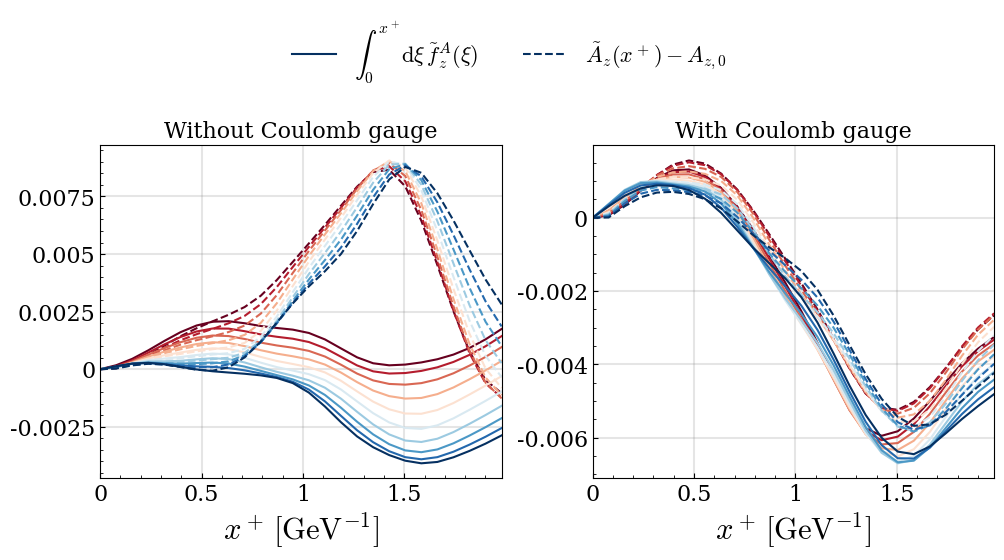

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib as mpl
import numpy as np  

plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ntraj = 10
cmap_rb = mpl.colormaps['RdBu'].resampled(20)
colors = [cmap_rb(i) for i in np.linspace(0, 1, ntraj)]

i = 2  # z direction
na = 5

# Without Coulomb gauge
ax = axes[0]
ax.tick_params(axis='both', which='major', direction='in')
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', direction='in')
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

for j in range(ntraj):
    ax.plot(xplus, da_no_coulomb[:, j, i, na].imag, linewidth=1.5, linestyle='--', color=colors[j])
    ax.plot(xplus, intfa_no_coulomb[:, j, i, na].imag, linewidth=1.5, color=colors[j])

ax.set_xlim([0, max(xplus)])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.set_xlabel(r"$x^+\,\mathrm{[GeV^{-1}]}$", fontsize=22)
ax.set_title('Without Coulomb gauge', fontsize=16)
ax.grid(color='gray', linestyle='-', linewidth=1.5, alpha=0.2)

# With Coulomb gauge
ax = axes[1]
ax.tick_params(axis='both', which='major', direction='in')
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', direction='in')
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

for j in range(ntraj):
    ax.plot(xplus, da_coulomb[:, j, i, na].imag, linewidth=1.5, linestyle='--', color=colors[j])
    ax.plot(xplus, intfa_coulomb[:, j, i, na].imag, linewidth=1.5, color=colors[j])

ax.set_xlim([0, max(xplus)])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.set_xlabel(r"$x^+\,\mathrm{[GeV^{-1}]}$", fontsize=22)
ax.set_title(f'With Coulomb gauge', fontsize=16)
ax.grid(color='gray', linestyle='-', linewidth=1.5, alpha=0.2)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=colors[ntraj-1], lw=1.5, linestyle='-', label=r'$\int_0^{x^+}\mathrm{d}\xi\,\tilde{f}_z^A(\xi)$'),
    Line2D([0], [0], color=colors[ntraj-1], lw=1.5, linestyle='--', label=r'$\tilde{A}_z(x^+)-A_{z,0}$'),
]
    
fig.legend(handles=legend_elements, fontsize=16, frameon=False, ncol=2, loc='lower center', bbox_to_anchor=(0.5, 0.92))

plt.tight_layout(rect=[0, 0, 1, 0.92])
# plt.savefig(f'intfa_deltaa_z_{quark}_n_{N}_{coulomb_gauge_mode}.png', facecolor='w', dpi=600) 
plt.show()

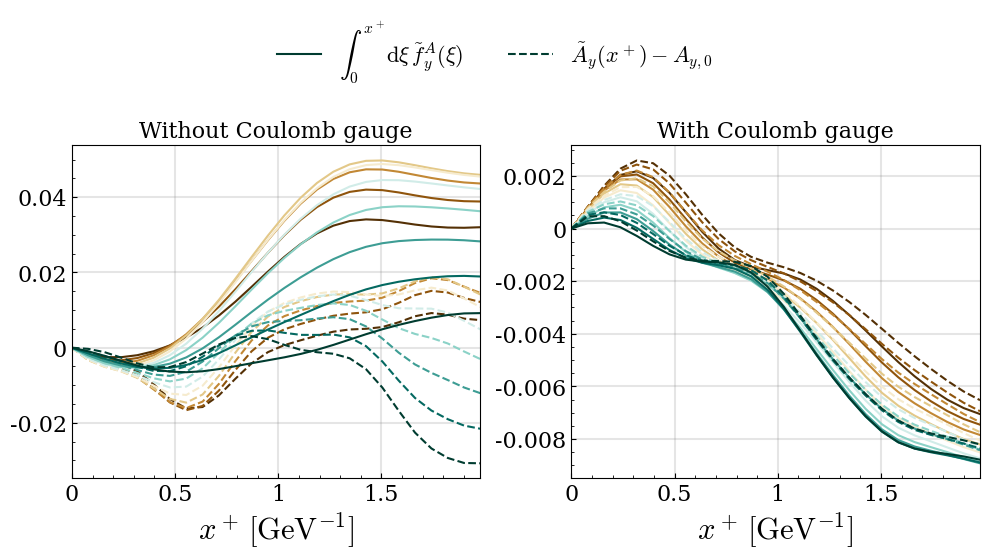

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib as mpl
import numpy as np  

plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ntraj = 10
cmap_rb = cmap_rb = mpl.colormaps['BrBG'].resampled(20)
colors = [cmap_rb(i) for i in np.linspace(0, 1, ntraj)]

i = 1  # y direction
na = 5

# Without Coulomb gauge
ax = axes[0]
ax.tick_params(axis='both', which='major', direction='in')
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', direction='in')
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

for j in range(ntraj):
    ax.plot(xplus, da_no_coulomb[:, j, i, na].imag, linewidth=1.5, linestyle='--', color=colors[j])
    ax.plot(xplus, intfa_no_coulomb[:, j, i, na].imag, linewidth=1.5, color=colors[j])

ax.set_xlim([0, max(xplus)])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.set_xlabel(r"$x^+\,\mathrm{[GeV^{-1}]}$", fontsize=22)
ax.set_title('Without Coulomb gauge', fontsize=16)
ax.grid(color='gray', linestyle='-', linewidth=1.5, alpha=0.2)

# With Coulomb gauge
ax = axes[1]
ax.tick_params(axis='both', which='major', direction='in')
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', direction='in')
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

for j in range(ntraj):
    ax.plot(xplus, da_coulomb[:, j, i, na].imag, linewidth=1.5, linestyle='--', color=colors[j])
    ax.plot(xplus, intfa_coulomb[:, j, i, na].imag, linewidth=1.5, color=colors[j])

ax.set_xlim([0, max(xplus)])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.set_xlabel(r"$x^+\,\mathrm{[GeV^{-1}]}$", fontsize=22)
ax.set_title(f'With Coulomb gauge', fontsize=16)
ax.grid(color='gray', linestyle='-', linewidth=1.5, alpha=0.2)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=colors[ntraj-1], lw=1.5, linestyle='-', label=r'$\int_0^{x^+}\mathrm{d}\xi\,\tilde{f}_y^A(\xi)$'),
    Line2D([0], [0], color=colors[ntraj-1], lw=1.5, linestyle='--', label=r'$\tilde{A}_y(x^+)-A_{y,0}$'),
]

fig.legend(handles=legend_elements, fontsize=16, frameon=False, ncol=2, loc='lower center', bbox_to_anchor=(0.5, 0.92))

plt.tight_layout(rect=[0, 0, 1, 0.92])
# plt.savefig(f'intfa_deltaa_y_{quark}_n_{N}_{coulomb_gauge_mode}.png', facecolor='w', dpi=600) 
plt.show()

---
### $\delta A$ vs $\delta\tilde{A}$ comparison

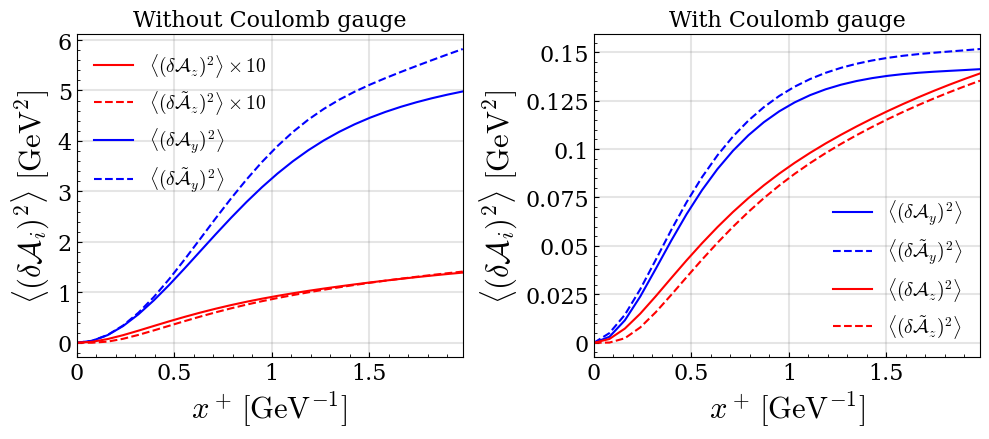

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# Without Coulomb gauge
ax = axes[0]
ax.tick_params(axis='both', which='major', direction='in')
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', direction='in')
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

i = 1
line1, = ax.plot(xplus, da_sq_no_coulomb[:, i], linewidth=1.5, color='blue')
line2, = ax.plot(xplus, da_transp_sq_no_coulomb[:, i], linewidth=1.5, color='blue', linestyle='--')

i = 2
line3, = ax.plot(xplus, da_sq_no_coulomb[:, i]*10, linewidth=1.5, color='red')
line4, = ax.plot(xplus, da_transp_sq_no_coulomb[:, i]*10, linewidth=1.5, color='red', linestyle='--')

ax.set_xlim([0, max(xplus)])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.set_xlabel(r"$x^+\,\mathrm{[GeV^{-1}]}$", fontsize=22)
ax.set_ylabel(r"$\langle (\delta \mathcal{A}_i)^2\rangle\,\,\mathrm{[GeV^2]}$", fontsize=22)
ax.set_title('Without Coulomb gauge', fontsize=16)
ax.grid(color='gray', linestyle='-', linewidth=1.5, alpha=0.2)
ax.legend([line3, line4, line1, line2], 
          [r"$\langle (\delta \mathcal{A}_z)^2\rangle\times 10$", 
           r"$\langle (\delta \tilde{\mathcal{A}}_z)^2\rangle\times 10$", 
           r"$\langle (\delta \mathcal{A}_y)^2\rangle$", 
           r"$\langle (\delta \tilde{\mathcal{A}}_y)^2\rangle$"], 
          fontsize=14, frameon=False, loc='upper left')

# With Coulomb gauge
ax = axes[1]
ax.tick_params(axis='both', which='major', direction='in')
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', direction='in')
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

i = 1
line1, = ax.plot(xplus, da_sq_coulomb[:, i], linewidth=1.5, color='blue')
line2, = ax.plot(xplus, da_transp_sq_coulomb[:, i], linewidth=1.5, color='blue', linestyle='--')

i = 2
line3, = ax.plot(xplus, da_sq_coulomb[:, i], linewidth=1.5, color='red')
line4, = ax.plot(xplus, da_transp_sq_coulomb[:, i], linewidth=1.5, color='red', linestyle='--')

ax.set_xlim([0, max(xplus)])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
ax.set_xlabel(r"$x^+\,\mathrm{[GeV^{-1}]}$", fontsize=22)
ax.set_ylabel(r"$\langle (\delta \mathcal{A}_i)^2\rangle\,\,\mathrm{[GeV^2]}$", fontsize=22)
ax.set_title(f'With Coulomb gauge', fontsize=16)
ax.grid(color='gray', linestyle='-', linewidth=1.5, alpha=0.2)
ax.legend([line1, line2, line3, line4], 
          [r"$\langle (\delta \mathcal{A}_y)^2\rangle$", 
           r"$\langle (\delta \tilde{\mathcal{A}}_y)^2\rangle$", 
           r"$\langle (\delta \mathcal{A}_z)^2\rangle$", 
           r"$\langle (\delta \tilde{\mathcal{A}}_z)^2\rangle$"], 
          fontsize=14, frameon=False, loc='lower right')

plt.tight_layout()
# plt.savefig(f'delta_a_delta_atilde_{quark}_n_{N}_{coulomb_gauge_mode}.png', facecolor='w', dpi=600)
plt.show()

---
### Decomposition: $\langle (\delta p^{\mathrm{kin}})^2 \rangle = \langle (\delta p^{\mathrm{can}})^2 \rangle + \langle (\delta \mathcal{A})^2 \rangle + 2\langle \delta p^{\mathrm{can}} \delta \mathcal{A} \rangle$

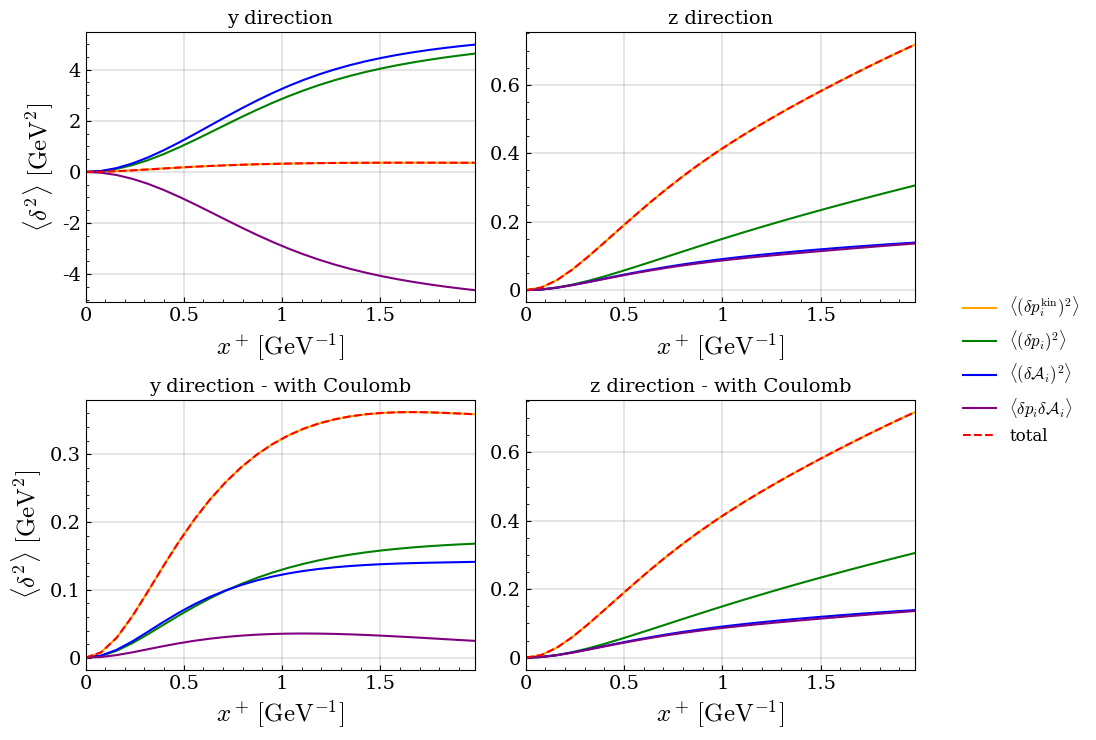

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5)) 

labels = ['x', 'y', 'z']

# Row 0: Without Coulomb gauge
for col, i in enumerate([1, 2]):  # y and z directions
    ax = axes[0, col]
    
    line1, = ax.plot(xplus, dpkin_sq_no_coulomb[:, i], linewidth=1.5, color='orange')
    line2, = ax.plot(xplus, dpcan_sq_no_coulomb[:, i], linewidth=1.5, color='green')
    line3, = ax.plot(xplus, da_sq_no_coulomb[:, i], linewidth=1.5, color='blue')
    line4, = ax.plot(xplus, dpcanda_no_coulomb[:, i], linewidth=1.5, color='purple')
    # convention Alatt = -igaA, so mixed term delta p * delta A is with +
    line5, = ax.plot(xplus, dpcan_sq_no_coulomb[:, i] + da_sq_no_coulomb[:, i] + 2 * dpcanda_no_coulomb[:, i], linewidth=1.5, color='red', linestyle="--")

    ax.set_xlim([0, max(xplus)])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.set_xlabel(r"$x^+\,\mathrm{[GeV^{-1}]}$", fontsize=18)
    ax.grid(color='gray', linestyle='-', linewidth=1.5, alpha=0.2)
    ax.tick_params(axis='both', which='major', direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', direction='in')
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_title(f'{labels[i]} direction', fontsize=14)

axes[0, 0].set_ylabel(r"$\langle \delta^2\rangle\,\,\mathrm{[GeV^2]}$", fontsize=18)

# Row 1: With Coulomb gauge
for col, i in enumerate([1, 2]):  # y and z directions
    ax = axes[1, col]
    
    ax.plot(xplus, dpkin_sq_coulomb[:, i], linewidth=1.5, color='orange')
    ax.plot(xplus, dpcan_sq_coulomb[:, i], linewidth=1.5, color='green')
    ax.plot(xplus, da_sq_coulomb[:, i], linewidth=1.5, color='blue')
    ax.plot(xplus, dpcanda_coulomb[:, i], linewidth=1.5, color='purple')
    ax.plot(xplus, dpcan_sq_coulomb[:, i] + da_sq_coulomb[:, i] + 2 * dpcanda_coulomb[:, i], linewidth=1.5, color='red', linestyle="--")

    ax.set_xlim([0, max(xplus)])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.set_xlabel(r"$x^+\,\mathrm{[GeV^{-1}]}$", fontsize=18)
    ax.grid(color='gray', linestyle='-', linewidth=1.5, alpha=0.2)
    ax.tick_params(axis='both', which='major', direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', direction='in')
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_title(f'{labels[i]} direction - with Coulomb', fontsize=14)

axes[1, 0].set_ylabel(r"$\langle \delta^2\rangle\,\,\mathrm{[GeV^2]}$", fontsize=18)

# Single legend outside the plot on the right
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='orange', lw=1.5, label=r"$\langle (\delta p^\mathrm{kin}_i)^2\rangle$"),
    Line2D([0], [0], color='green', lw=1.5, label=r"$\langle (\delta p_i)^2\rangle$"),
    Line2D([0], [0], color='blue', lw=1.5, label=r"$\langle (\delta \mathcal{A}_i)^2\rangle$"),
    Line2D([0], [0], color='purple', lw=1.5, label=r"$\langle \delta p_i \delta \mathcal{A}_i\rangle$"),
    Line2D([0], [0], color='red', lw=1.5, linestyle='--', label=r"total"),
]

fig.legend(handles=legend_elements, fontsize=12, frameon=False, loc='center right', bbox_to_anchor=(1.0, 0.5))

plt.tight_layout(rect=[0, 0, 0.85, 1])
# plt.savefig(f'delta_sq_delta_a_{quark}_n_{N}_{coulomb_gauge_mode}.png', facecolor='w', dpi=600, bbox_inches='tight')
plt.show()

---
### Decomposition with transported fields: $\langle (\delta p^{\mathrm{kin}})^2 \rangle = \langle (\delta p^{\mathrm{can}})^2 \rangle + \langle (\delta \tilde{\mathcal{A}})^2 \rangle + 2\langle \delta p^{\mathrm{can}} \delta \tilde{\mathcal{A}} \rangle$

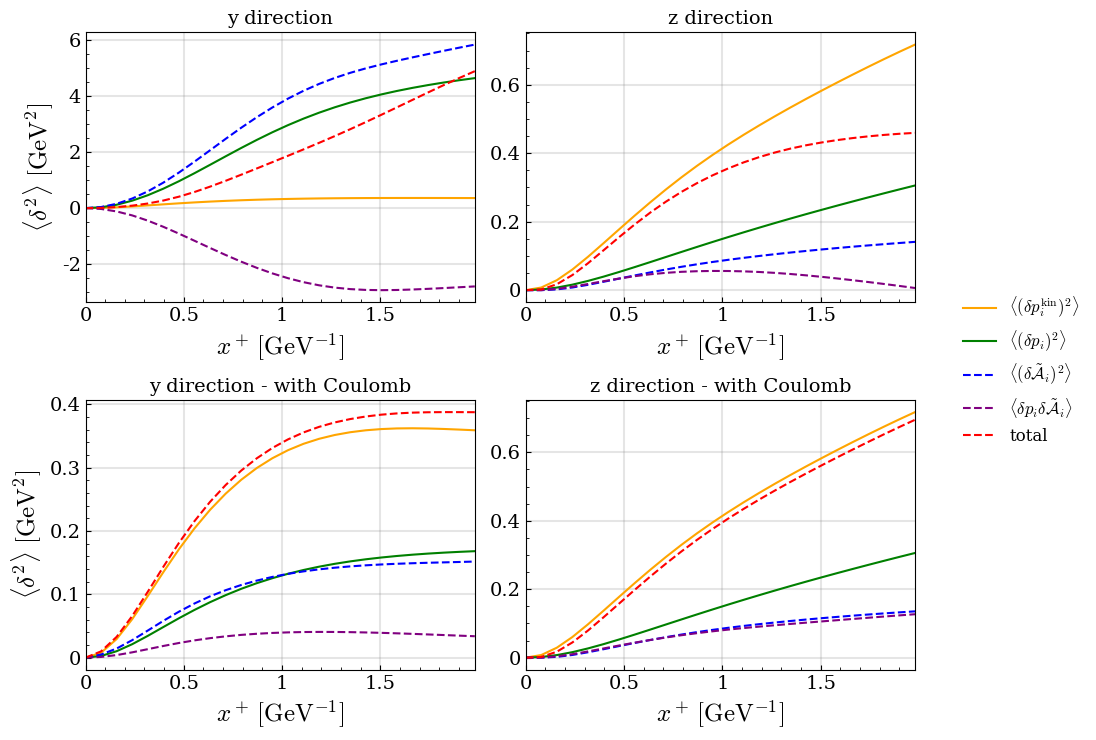

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5)) 

labels = ['x', 'y', 'z']

# Row 0: Without Coulomb gauge
for col, i in enumerate([1, 2]):  # y and z directions
    ax = axes[0, col]
    
    ax.plot(xplus, dpkin_sq_no_coulomb[:, i], linewidth=1.5, color='orange')
    ax.plot(xplus, dpcan_sq_no_coulomb[:, i], linewidth=1.5, color='green')
    ax.plot(xplus, da_transp_sq_no_coulomb[:, i], linewidth=1.5, color='blue', linestyle='--')
    ax.plot(xplus, dpcanda_transp_no_coulomb[:, i], linewidth=1.5, color='purple', linestyle='--')
    ax.plot(xplus, dpcan_sq_no_coulomb[:, i] + da_transp_sq_no_coulomb[:, i] + 2 * dpcanda_transp_no_coulomb[:, i], linewidth=1.5, color='red', linestyle='--')

    ax.set_xlim([0, max(xplus)])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.set_xlabel(r"$x^+\,\mathrm{[GeV^{-1}]}$", fontsize=18)
    ax.grid(color='gray', linestyle='-', linewidth=1.5, alpha=0.2)
    ax.tick_params(axis='both', which='major', direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', direction='in')
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_title(f'{labels[i]} direction', fontsize=14)

axes[0, 0].set_ylabel(r"$\langle \delta^2\rangle\,\,\mathrm{[GeV^2]}$", fontsize=18)

# Row 1: With Coulomb gauge
for col, i in enumerate([1, 2]):  # y and z directions
    ax = axes[1, col]
    
    ax.plot(xplus, dpkin_sq_coulomb[:, i], linewidth=1.5, color='orange')
    ax.plot(xplus, dpcan_sq_coulomb[:, i], linewidth=1.5, color='green')
    ax.plot(xplus, da_transp_sq_coulomb[:, i], linewidth=1.5, color='blue', linestyle='--')
    ax.plot(xplus, dpcanda_transp_coulomb[:, i], linewidth=1.5, color='purple', linestyle='--')
    ax.plot(xplus, dpcan_sq_coulomb[:, i] + da_transp_sq_coulomb[:, i] + 2 * dpcanda_transp_coulomb[:, i], linewidth=1.5, color='red', linestyle='--')

    ax.set_xlim([0, max(xplus)])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.set_xlabel(r"$x^+\,\mathrm{[GeV^{-1}]}$", fontsize=18)
    ax.grid(color='gray', linestyle='-', linewidth=1.5, alpha=0.2)
    ax.tick_params(axis='both', which='major', direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', direction='in')
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_title(f'{labels[i]} direction - with Coulomb', fontsize=14)

axes[1, 0].set_ylabel(r"$\langle \delta^2\rangle\,\,\mathrm{[GeV^2]}$", fontsize=18)

# Single legend outside the plot on the right
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='orange', lw=1.5, label=r"$\langle (\delta p^\mathrm{kin}_i)^2\rangle$"),
    Line2D([0], [0], color='green', lw=1.5, label=r"$\langle (\delta p_i)^2\rangle$"),
    Line2D([0], [0], color='blue', lw=1.5, linestyle='--', label=r"$\langle (\delta \tilde{\mathcal{A}}_i)^2\rangle$"),
    Line2D([0], [0], color='purple', lw=1.5, linestyle='--', label=r"$\langle \delta p_i \delta \tilde{\mathcal{A}}_i\rangle$"),
    Line2D([0], [0], color='red', lw=1.5, linestyle='--', label=r"total"),
]

fig.legend(handles=legend_elements, fontsize=12, frameon=False, loc='center right', bbox_to_anchor=(1.0, 0.5))

plt.tight_layout(rect=[0, 0, 0.85, 1])
# plt.savefig(f'delta_sq_delta_atilde_{quark}_n_{N}_{coulomb_gauge_mode}.png', facecolor='w', dpi=600, bbox_inches='tight')
plt.show()

---